In [1]:
import os
import torch
from open_clip import create_model_from_pretrained, get_tokenizer
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch.nn.functional as F

In [2]:
# ------------------------------
# CONFIGURATION
# ------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Real directories (200 images each)
REAL_MILD_DIR   = "/data/liangz2/image_quality/real_images/mild"    # 200 mild pneumonia CXRs
REAL_SEVERE_DIR = "/data/liangz2/image_quality/real_images/severe"  # 200 severe pneumonia CXRs

# Synthetic directories for the 12 types:
SYNTH_DIRS = {
    "SD21_i2i_mild":   "/data/liangz2/image_quality/fake_images/sd21/sd21_i2i_mild",      # #1
    "SD21_i2i_severe": "/data/liangz2/image_quality/fake_images/sd21/sd21_i2i_severe",    # #2
    "SD21_t2i_mild":   "/data/liangz2/image_quality/fake_images/sd21/sd21_t2i_mild",      # #3
    "SD21_t2i_severe": "/data/liangz2/image_quality/fake_images/sd21/sd21_t2i_severe",    # #4
    "SD35_i2i_mild":   "/data/liangz2/image_quality/fake_images/sd35/sd35_i2i_mild",      # #5
    "SD35_i2i_severe": "/data/liangz2/image_quality/fake_images/sd35/sd35_i2i_severe",    # #6
    "SD35_t2i_mild":   "/data/liangz2/image_quality/fake_images/sd35/sd35_t2i_mild",      # #7
    "SD35_t2i_severe": "/data/liangz2/image_quality/fake_images/sd35/sd35_t2i_severe",    # #8
    "StyleGAN2_mild":  "/data/liangz2/image_quality/fake_images/stylegan2/mild",     # #9
    "StyleGAN2_severe":"/data/liangz2/image_quality/fake_images/stylegan2/severe",   # #10
    "StyleGAN3_mild":  "/data/liangz2/image_quality/fake_images/stylegan3/mild",     # #11
    "StyleGAN3_severe":"/data/liangz2/image_quality/fake_images/stylegan3/severe",   # #12
}

# List of thresholds to evaluate
THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25]

# Output CSV for summary
OUTPUT_CSV = "/data/liangz2/biomedclip_model/coverage_comparison_summary.csv"

def get_image_files(img_dir):
    image_files = []
    for subdir, _, files in os.walk(img_dir):
        for file in files:
            if file.endswith(('.png', '.jpg', '.jpeg')):
                # Get the absolute path and add it to the list
                image_files.append(os.path.abspath(os.path.join(subdir, file)))
    return image_files

In [3]:
real_img_dir_1 = '/data/liangz2/image_quality/real_images/mild'
real_img_dir_2 = '/data/liangz2/image_quality/real_images/severe'
sd21_i2i_mild_dir = '/data/liangz2/image_quality/fake_images/sd21/sd21_i2i_mild'
sd21_i2i_severe_dir = '/data/liangz2/image_quality/fake_images/sd21/sd21_i2i_severe'
sd21_t2i_mild_dir = '/data/liangz2/image_quality/fake_images/sd21/sd21_t2i_mild'
sd21_t2i_severe_dir = '/data/liangz2/image_quality/fake_images/sd21/sd21_t2i_severe'
sd35_i2i_mild_dir = '/data/liangz2/image_quality/fake_images/sd35/sd35_i2i_mild'
sd35_i2i_severe_dir = '/data/liangz2/image_quality/fake_images/sd35/sd35_i2i_severe'
sd35_t2i_mild_dir = '/data/liangz2/image_quality/fake_images/sd35/sd35_t2i_mild'
sd35_t2i_severe_dir = '/data/liangz2/image_quality/fake_images/sd35/sd35_t2i_severe'
stylegan2_mild_dir = '/data/liangz2/image_quality/fake_images/stylegan2/mild'
stylegan2_severe_dir = '/data/liangz2/image_quality/fake_images/stylegan2/severe'
stylegan3_mild_dir = '/data/liangz2/image_quality/fake_images/stylegan3/mild'
stylegan3_severe_dir = '/data/liangz2/image_quality/fake_images/stylegan3/severe'

real_mild_images = get_image_files(real_img_dir_1)
real_severe_images = get_image_files(real_img_dir_2)
sd21_i2i_mild_images = get_image_files(sd21_i2i_mild_dir)
sd21_i2i_severe_images = get_image_files(sd21_i2i_severe_dir)
sd21_t2i_mild_images = get_image_files(sd21_t2i_mild_dir)
sd21_t2i_severe_images = get_image_files(sd21_t2i_severe_dir)
sd35_i2i_mild_images = get_image_files(sd35_i2i_mild_dir)
sd35_i2i_severe_images = get_image_files(sd35_i2i_severe_dir)
sd35_t2i_mild_images = get_image_files(sd35_t2i_mild_dir)
sd35_t2i_severe_images = get_image_files(sd35_t2i_severe_dir)
stylegan2_mild_images = get_image_files(stylegan2_mild_dir)
stylegan2_severe_images = get_image_files(stylegan2_severe_dir)
stylegan3_mild_images = get_image_files(stylegan3_mild_dir)
stylegan3_severe_images = get_image_files(stylegan3_severe_dir)

print(f"total real mild images: {len(real_mild_images)}")
print(f"total real severe images: {len(real_severe_images)}")
print(f"total sd21 i2i mild images: {len(sd21_i2i_mild_images)}")
print(f"total sd21 i2i severe images: {len(sd21_i2i_severe_images)}")
print(f"total sd21 t2i mild images: {len(sd21_t2i_mild_images)}")
print(f"total sd21 t2i severe images: {len(sd21_t2i_severe_images)}")
print(f"total sd35 i2i mild images: {len(sd35_i2i_mild_images)}")
print(f"total sd35 i2i severe images: {len(sd35_i2i_severe_images)}")
print(f"total sd35 t2i mild images: {len(sd35_t2i_mild_images)}")
print(f"total sd35 t2i severe images: {len(sd35_t2i_severe_images)}")
print(f"total stylegan2 mild images: {len(stylegan2_mild_images)}")
print(f"total stylegan2 severe images: {len(stylegan2_severe_images)}")
print(f"total stylegan3 mild images: {len(stylegan3_mild_images)}")
print(f"total stylegan3 severe images: {len(stylegan3_severe_images)}")

total real mild images: 200
total real severe images: 200
total sd21 i2i mild images: 1000
total sd21 i2i severe images: 1000
total sd21 t2i mild images: 1000
total sd21 t2i severe images: 1000
total sd35 i2i mild images: 1000
total sd35 i2i severe images: 1000
total sd35 t2i mild images: 1000
total sd35 t2i severe images: 1000
total stylegan2 mild images: 1000
total stylegan2 severe images: 1000
total stylegan3 mild images: 1000
total stylegan3 severe images: 1000


In [4]:
# ------------------------------
# 1. Load BiomedCLIP (visual encoder + preprocess)
# ------------------------------

MODEL_NAME = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
SAVE_PATH  = "./biomedclip_model/biomedclip_visual_finetuned.pth"

vision_model, processor = create_model_from_pretrained(MODEL_NAME, return_transform=True)
vision_model.visual.load_state_dict(torch.load(SAVE_PATH, map_location="cpu"))
vision_model = vision_model.to(DEVICE).eval()

print(f"Loaded fine‐tuned visual weights from: {SAVE_PATH} is on device: {DEVICE}")

Loaded fine‐tuned visual weights from: ./biomedclip_model/biomedclip_visual_finetuned.pth is on device: cuda


In [5]:
# ----------------------------------------
# 2. Helper: batch‐compute embeddings for all images in a folder
# ----------------------------------------
def load_embeddings(folder: str, batch_size: int = 32):
    """
    Iterate over all images in `folder`, compute BiomedCLIP embeddings in batches,
    and return:
      - embs: NumPy array of shape (N, D)
      - paths: list of length N with corresponding file paths
    """
    filenames = sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff"))
    ])
    paths = [os.path.join(folder, fn) for fn in filenames]
    all_embs = []

    for i in tqdm(range(0, len(paths), batch_size), desc=f"Embedding {os.path.basename(folder)}"):
        batch_paths = paths[i : i + batch_size]
        imgs = [Image.open(p).convert("RGB") for p in batch_paths]
        # processor resizes to 224×224 and normalizes
        pix = torch.stack([processor(img) for img in imgs], dim=0).to(DEVICE)  # (B, 3, 224, 224)

        with torch.no_grad():
            feats = vision_model.encode_image(pix)    # (B, D)
            feats = F.normalize(feats, dim=-1)        # unit‐normalize
        all_embs.append(feats.cpu().numpy())

    all_embs = np.concatenate(all_embs, axis=0)      # (N, D)
    return all_embs, paths

In [6]:
# ----------------------------------------
# 3. Embed the 200 real mild and 200 real severe CXRs
# ----------------------------------------
real_mild_embs, real_mild_paths     = load_embeddings(REAL_MILD_DIR, batch_size=32)
real_severe_embs, real_severe_paths = load_embeddings(REAL_SEVERE_DIR, batch_size=32)

real_mild_tensor   = torch.from_numpy(real_mild_embs).to(DEVICE)    # (200, D)
real_severe_tensor = torch.from_numpy(real_severe_embs).to(DEVICE)  # (200, D)

Embedding severe: 100%|██████████| 7/7 [00:02<00:00,  2.91it/s]


In [7]:
# ----------------------------------------
# 4. Pre‐compute embeddings for all 12 synthetic sets
# ----------------------------------------
synth_emb_dict = {}   # name -> (embs, paths, tensor)
for name, folder in SYNTH_DIRS.items():
    embs, paths = load_embeddings(folder, batch_size=32)
    synth_emb_dict[name] = {
        "embs":   embs,
        "paths":  paths,
        "tensor": torch.from_numpy(embs).to(DEVICE)  # (1000, D)
    }

Embedding severe: 100%|██████████| 32/32 [00:11<00:00,  2.77it/s]


In [8]:
# ----------------------------------------
# 5. Compute coverage for each generator & threshold
# ----------------------------------------
records = []
for name, data in synth_emb_dict.items():
    # Determine whether this is mild or severe synthetic
    if name.endswith("_mild"):
        real_tensor = real_mild_tensor
        n_real      = real_mild_embs.shape[0]      # 200
    else:
        real_tensor = real_severe_tensor
        n_real      = real_severe_embs.shape[0]    # 200

    synth_tensor = data["tensor"]                # (1000, D)
    n_synth      = data["embs"].shape[0]         # 1000

    # Compute pairwise cosine‐distance once
    with torch.no_grad():
        sim_matrix  = real_tensor @ synth_tensor.T   # (200, 1000)
        dist_matrix = 1.0 - sim_matrix                # (200, 1000)

    # For each threshold, compute coverage
    min_dist_per_real, _ = dist_matrix.min(dim=1)    # (200,)
    for thr in THRESHOLDS:
        covered_mask    = (min_dist_per_real < thr)           # boolean (200,)
        n_covered       = covered_mask.sum().item()
        coverage_frac   = n_covered / n_real

        records.append({
            "Generator":         name,
            "Severity":          "mild"  if name.endswith("_mild")   else "severe",
            "Num_Real":          n_real,
            "Num_Synth":         n_synth,
            "Threshold":         thr,
            "Num_Real_Covered":  n_covered,
            "Coverage_Fraction": coverage_frac,
            "Mean_Min_Dist":     min_dist_per_real.mean().item(),
            "Std_Min_Dist":      min_dist_per_real.std().item(),
        })


In [9]:
# ----------------------------------------
# 6. Build DataFrame & Save
# ----------------------------------------
summary_df = pd.DataFrame.from_records(records)
summary_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved summary to {OUTPUT_CSV}")
print(summary_df)

Saved summary to /data/liangz2/biomedclip_model/coverage_comparison_summary.csv
           Generator Severity  Num_Real  Num_Synth  Threshold  \
0      SD21_i2i_mild     mild       200       1000       0.05   
1      SD21_i2i_mild     mild       200       1000       0.10   
2      SD21_i2i_mild     mild       200       1000       0.15   
3      SD21_i2i_mild     mild       200       1000       0.20   
4      SD21_i2i_mild     mild       200       1000       0.25   
5    SD21_i2i_severe   severe       200       1000       0.05   
6    SD21_i2i_severe   severe       200       1000       0.10   
7    SD21_i2i_severe   severe       200       1000       0.15   
8    SD21_i2i_severe   severe       200       1000       0.20   
9    SD21_i2i_severe   severe       200       1000       0.25   
10     SD21_t2i_mild     mild       200       1000       0.05   
11     SD21_t2i_mild     mild       200       1000       0.10   
12     SD21_t2i_mild     mild       200       1000       0.15   
13     SD2

Saved coverage plot to ./biomedclip_model/coverage_vs_threshold_mild_severe.png


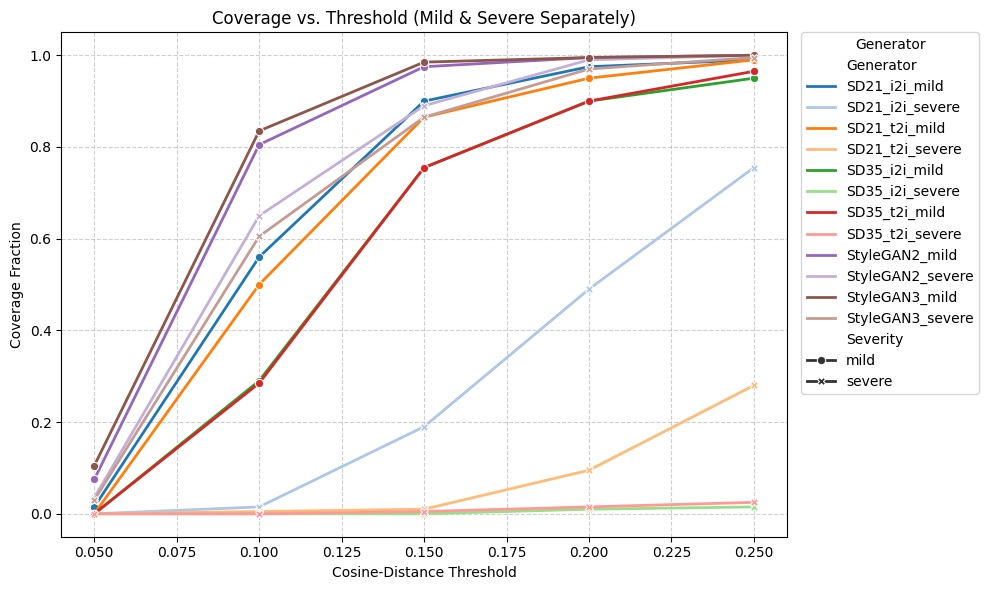

In [10]:
# ----------------------------------------
# 7. Visualize Coverage Curves
# ----------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the 'Threshold' column is numeric
summary_df["Threshold"] = summary_df["Threshold"].astype(float)

plt.figure(figsize=(10, 6))

# Use a seaborn palette with at least 12 distinct colors
palette = sns.color_palette("tab20", n_colors=len(SYNTH_DIRS))

sns.lineplot(
    data=summary_df,
    x="Threshold",               # <-- explicitly use the numeric 'Threshold' column
    y="Coverage_Fraction",
    hue="Generator",
    style="Severity",            # distinguish mild vs severe by line style
    markers=True,
    dashes=False,
    palette=palette,
    linewidth=2
)

plt.xlabel("Cosine-Distance Threshold")
plt.ylabel("Coverage Fraction")
plt.title("Coverage vs. Threshold (Mild & Severe Separately)")

# Place legend outside the plot
plt.legend(bbox_to_anchor=(1.02, 1),
           loc="upper left",
           borderaxespad=0,
           title="Generator")

plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()

plot_name = "./biomedclip_model/coverage_vs_threshold_mild_severe.png"
plt.savefig(plot_name, dpi=300)
print(f"Saved coverage plot to {plot_name}")

/tmp/ipykernel_1773045/1806351798.py:16: UserWarning: The palette list has more values (12) than needed (6), which may not be intended.
  sns.lineplot(
/tmp/ipykernel_1773045/1806351798.py:40: UserWarning: The palette list has more values (12) than needed (6), which may not be intended.
  sns.lineplot(


Saved coverage plot to ./biomedclip_model/coverage_vs_threshold_mild_severe_2.png


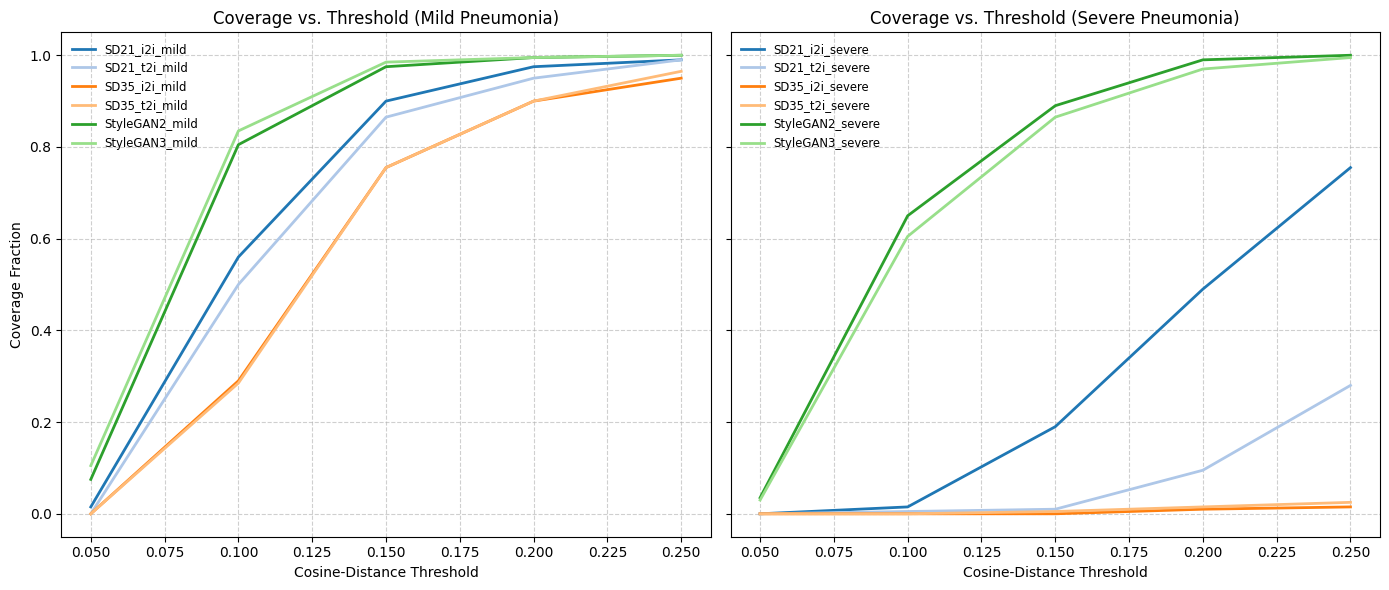

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Threshold' is numeric
summary_df["Threshold"] = summary_df["Threshold"].astype(float)

# Create 1×2 horizontal subplots: left for mild, right for severe
fig, (ax_mild, ax_severe) = plt.subplots(
    1, 2, figsize=(14, 6), sharey=True
)

# Choose a palette with enough distinct colors
palette = sns.color_palette("tab20", n_colors=len(SYNTH_DIRS))

# Plot mild pneumonia coverage on the left axis
sns.lineplot(
    data=summary_df[summary_df["Severity"] == "mild"],
    x="Threshold",
    y="Coverage_Fraction",
    hue="Generator",
    markers=True,
    dashes=False,
    palette=palette,
    linewidth=2,
    ax=ax_mild
)
ax_mild.set_title("Coverage vs. Threshold (Mild Pneumonia)")
ax_mild.set_xlabel("Cosine‐Distance Threshold")
ax_mild.set_ylabel("Coverage Fraction")
ax_mild.grid(linestyle="--", alpha=0.6)
ax_mild.legend(
    loc="upper left",
    fontsize="small",
    title_fontsize="small",
    markerscale=0.7,
    frameon=False
)

# Plot severe pneumonia coverage on the right axis
sns.lineplot(
    data=summary_df[summary_df["Severity"] == "severe"],
    x="Threshold",
    y="Coverage_Fraction",
    hue="Generator",
    markers=True,
    dashes=False,
    palette=palette,
    linewidth=2,
    ax=ax_severe
)
ax_severe.set_title("Coverage vs. Threshold (Severe Pneumonia)")
ax_severe.set_xlabel("Cosine‐Distance Threshold")
ax_severe.set_ylabel("")  # share y‐label with left
ax_severe.grid(linestyle="--", alpha=0.6)
ax_severe.legend(
    loc="upper left",
    fontsize="small",
    title_fontsize="small",
    markerscale=0.7,
    frameon=False
)

plt.tight_layout()

plot_name = "./biomedclip_model/coverage_vs_threshold_mild_severe_2.png"
plt.savefig(plot_name, dpi=300)
print(f"Saved coverage plot to {plot_name}")

In [20]:
# ------------------------------
# 2. Helper: get a single embedding
# ------------------------------
def get_embedding(image_path: str) -> torch.Tensor:
    """
    Load an image from disk, preprocess it (resize+normalize), and compute
    its BiomedCLIP image embedding. Returns a unit‐normalized 1D tensor of size D.
    """
    img = Image.open(image_path).convert("RGB")
    pix = processor(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat = vision_model.encode_image(pix)
        feat = F.normalize(feat, dim=-1)
    return feat.squeeze(0).cpu()

In [21]:
real_mild_image = real_mild_images[0]
img_embedding = get_embedding(real_mild_image)
print(f"Image embedding for {real_mild_image} has shape: {img_embedding.shape}")

Image embedding for /data/liangz2/image_quality/real_images/mild/chest_XR_100.png has shape: torch.Size([512])


In [23]:
# ------------------------------
# 3. Load all embeddings for a folder
# ------------------------------
def load_all_embeddings(folder: str, batch_size: int = 16):
    """
    Iterate over all image files in folder, compute BiomedCLIP embeddings in batches,
    and return:
      - embs: (N, D) NumPy array of embeddings
      - paths: list of length N with the corresponding file paths
    """
    filenames = sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff"))
    ])
    paths = [os.path.join(folder, fn) for fn in filenames]

    all_embs = []
    for i in tqdm(range(0, len(paths), batch_size), desc=f"Embedding {os.path.basename(folder)}"):
        batch_paths = paths[i : i + batch_size]
        imgs = [Image.open(p).convert("RGB") for p in batch_paths]
        pix = torch.stack([processor(img) for img in imgs], dim=0).to(DEVICE)  # (B, 3, 224, 224)
        with torch.no_grad():
            feats = vision_model.encode_image(pix)  # (B, D)
            feats = F.normalize(feats, dim=-1)
        all_embs.append(feats.cpu().numpy())

    all_embs = np.concatenate(all_embs, axis=0)  # (N, D)
    return all_embs, paths

# 3a) Real embeddings
real_embs, real_paths = load_all_embeddings(REAL_DIR, batch_size=16)
# 3b) Synthetic embeddings
synth_embs, synth_paths = load_all_embeddings(SYNTH_DIR, batch_size=16)

# ------------------------------
# 4. Compute pairwise cosine-distance matrix
# ------------------------------
real_tensor  = torch.from_numpy(real_embs).to(DEVICE)   # (N_real, D)
synth_tensor = torch.from_numpy(synth_embs).to(DEVICE)  # (N_synth, D)

with torch.no_grad():
    sim_matrix  = real_tensor @ synth_tensor.T         # (N_real, N_synth)
    dist_matrix = 1.0 - sim_matrix                      # cosine-distance

# ------------------------------
# 5. Compute coverage per real image
# ------------------------------
min_dist_per_real, _ = dist_matrix.min(dim=1)          # (N_real,)
covered_mask = (min_dist_per_real < COVERAGE_THRESHOLD)

n_covered = covered_mask.sum().item()
n_real    = real_embs.shape[0]
coverage_fraction = n_covered / n_real

print(f"Coverage threshold (cosine-distance): {COVERAGE_THRESHOLD:.3f}")
print(f"Real images covered: {n_covered} / {n_real}")
print(f"Coverage fraction: {coverage_fraction*100:.2f}%")

Embedding sd21_i2i_mild: 100%|██████████| 63/63 [00:15<00:00,  4.17it/s]


Coverage threshold (cosine-distance): 0.200
Real images covered: 195 / 200
Coverage fraction: 97.50%
